In [8]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lotka-Volterra

In [9]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dts = np.logspace(-2, 0, 11).tolist()
t_spans = sorted([(0, 3*i) for i in range(1, 10 + 1)], reverse=True)

t_span_test = (0, 50)

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
    'np_seed': 0,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': 0.01,
    't_eval_train': None, 'dt_train': dts, 't_span_train': t_spans,
    'train_interpolation_dt': None,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0    
}

results = run_experiment(experiment_config, use_ESINDy=True, use_ridge=True, generate_prediction=True)

rows are dt_train. there are 11 rows.
columns are t_span_train. there are 10 columns.
step 1 of 11


100%|██████████| 10/10 [00:26<00:00,  2.67s/it]


step 2 of 11


100%|██████████| 10/10 [00:12<00:00,  1.29s/it]


step 3 of 11


...

100%|██████████| 10/10 [00:10<00:00,  1.00s/it]


step 10 of 11


100%|██████████| 10/10 [00:10<00:00,  1.02s/it]


step 11 of 11


100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


rows are dt_train. there are 11 rows.
columns are t_span_train. there are 10 columns.


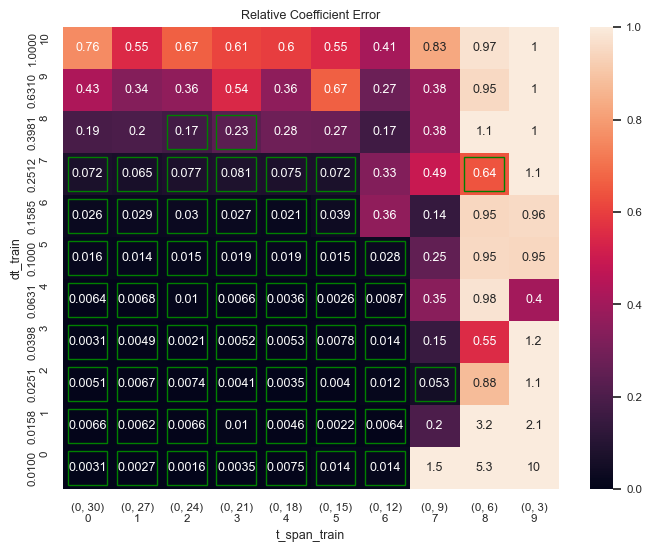

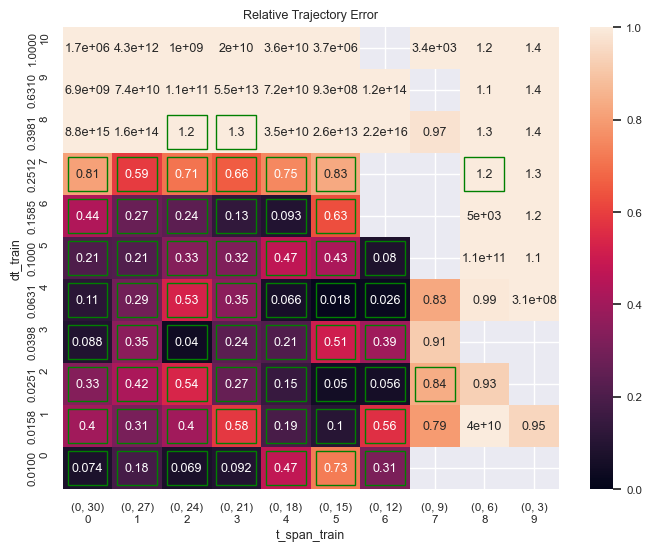

In [10]:
plot_heatmaps(experiment_config, results)

x0' = + 1.07300 x0 + -0.38099 x0 x1 
x1' = + -0.39256 x1 + 0.09519 x0 x1 


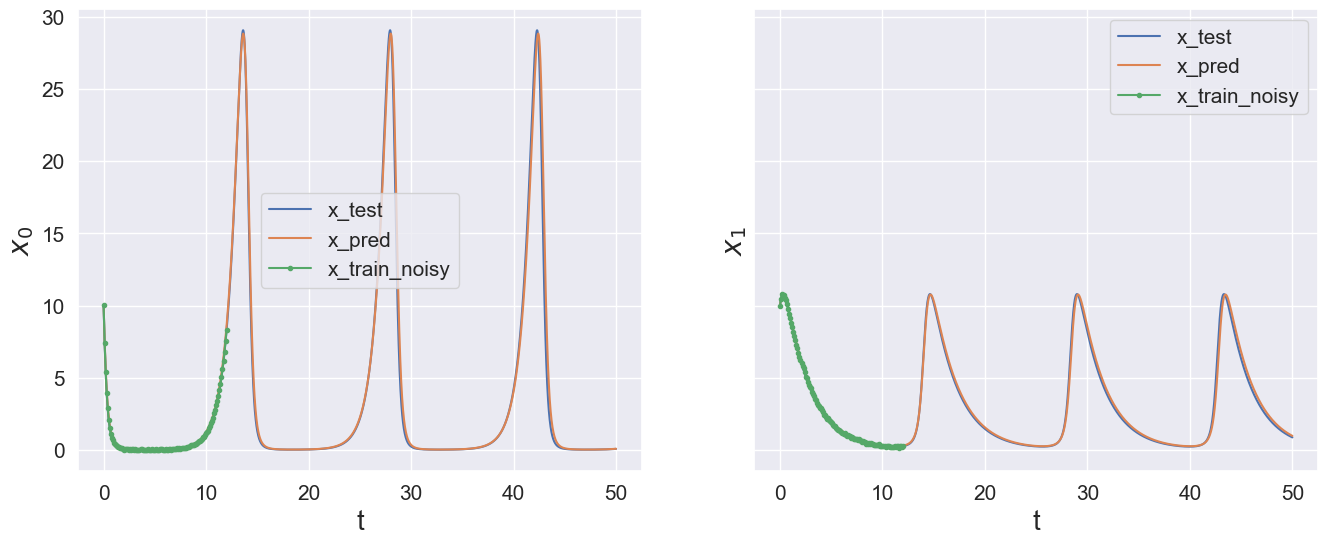

In [17]:
SMALL_SIZE = 15
MEDIUM_SIZE = 20

# plt.rcdefaults()
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize

display_single_result(experiment_config, results, 6, 5, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

# Duffing Oscillator

In [12]:
# duffing_oscillator_rhs = generate_duffing_oscillator_rhs(*default_params['duffing_oscillator'])
# true_coeffs = generate_duffing_oscillator_true_coefficients(*default_params['duffing_oscillator'])
# x0 = default_x0['duffing_oscillator']

# dts = np.logspace(-2, 0, 11).tolist()
# t_spans = sorted([(0, 4*i) for i in range(1, 10 + 1)], reverse=True)

# t_span_test = (0, 50)

# experiment_config2 = {
#     # define fixed parameters
#     'rhs': duffing_oscillator_rhs,
#     'derivative_approximation': dxdt_finite_difference,
#     't_eval_test': np.arange(t_span_test[0], t_span_test[1] + 0.01, 0.01),
#     'np_seed': 0,
#     'true_coeffs': true_coeffs,
#     # define parameters that can be lists
#     'x0': x0, 'noise_level': 0.01,
#     't_eval_train': None, 'dt_train': dts, 't_span_train': t_spans,
#     'train_interpolation_dt': None,
#     'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0    
# }

# results2 = run_experiment(experiment_config2)

In [13]:
# plot_heatmaps(experiment_config2, results2)

In [14]:
# display_single_result(experiment_config2, results2, 5, 5, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])